# Assignment 1 - Particle filter

- **Topic:** Designing a particle filter to estimate the position using magnetic field information
- **Assessment:** The assignment will go through a pass/fail check.


- **Deadline:**  28-02-2025, 17:00
- **Submitting: SUBMIT ONLY `assignment1_groupNumber.ipynb` TO BRIGHTSPACE**. 
where groupNumber is your groupnumber


## Instructions
**Installation:** The implementation is tested with python 3.9.12 and packages including
-   numpy version: 1.26.4
-   scipy version: 1.13.0
-   matplotlib version: 3.5.1


Other (not too old or new) versions will probably also work.

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `GP.py`, `helper.py` and `linAlg.py` and the dictionary `modelParameters` as this might result in breaking the assignment.



## AI Related Policy
We strongly discourage you to use AI tools for implementation assistance. It is your understanding of the problem that is tested in the final exam.


## Information
Please fill in your group number, names and student numbers in the cell below.



In [57]:
''' YOUR ANSWER HERE '''
groupNumber = 18

STUDENT_1_NAME = "Deepika Phadke"
STUDENT_1_STUDENT_NUMBER = "6250459"

STUDENT_2_NAME = "Abhishek Reddy"
STUDENT_2_STUDENT_NUMBER = "6295142"

# raise NotImplementedError()

## Objectives

#### Goal

The goal of this assignment is to estimate the position $ \mathbf{p}_t $ of an agent. The agent moves in an indoor environment and gets information about its approximate change in position $ \Delta \mathbf{p}_t $ at every time-step. To model this, you may assume a linear dynamic model of the form:
$$\mathbf{p}_{t + 1} = \mathbf{p}_t + \Delta \mathbf{p}_{t+1} + \mathbf{w}_{t+1}$$

Where:

- $\mathbf{p}_t$ is a 3-dimensional position vector of the agent at time $t$. 

- $\Delta \mathbf{p}_t$ is the change in positon.

- $\mathbf{w}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{Q})$ is Gaussian white noise.

- $ \mathbf{Q} \in \mathbb{R}^{3 \times 3} $ is the covariance of the process noise.

Since the information of the change in position $ \Delta \mathbf{p}_t$ contains errors, the position estimates from the dynamic model will drift. This means that over time, the agent will lose track of where it actually is. To remedy this, the agent is carrying a magnetometer, and has a map of the magnetic field. The magnetometer samples a measurement of the magnetic field $\mathbf{y}_t$ at every position $\mathbf{p}_t$. The map of the magnetic field is modeled by a non-linear function: a reduced rank Gaussian process (you do not need to understand, model or change the GP model, only to call the function evaluation). This results in the non-linear measurement model:
$$ \mathbf{y}_t = f(\mathbf{p}_t) + \mathbf{v}_t $$

Where:

- $\mathbf{y}_t$ is a 3-dimensional measurement vector of the magnetic field at time-step $t$.

- $f(\cdot)$ is the reduced rank Gaussian process function.

- $\mathbf{v}_t \sim \mathcal{N}(0_{3 \times 1}, \mathbf{R})$ is Gaussian white noise.

- $ \mathbf{R} \in \mathbb{R}^{3 \times 3} $ is the covariance of the measurement noise.


#### First load in the data
To start, first load in the data below
All variables you will use are numpy arrays, where
- `magnetometerMeasurements` $\in \mathbb{R}^{3 \times N}$ is a numpy array containing the magnetometer measurements
- `magnetometerInitialPosition` $\in \mathbb{R}^{3 \times 1}$ is a numpy array containing the initial position of the magnetometer
- `deltaMagnetometerPositions` $\in \mathbb{R}^{3 \times N}$ is a numpy array containing the change in position of the magnetometer

#### Warning
- Additionally you are provided with a dictionary modelParameters which is used in creating magnetic field maps. DO NOT CHANGE dictionary as this might break the assignment. To create the particle filter you DO NOT need this dictionary.

In [58]:
''' DO NOT CHANGE THE CODE BELOW '''
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import GP as GP
import linAlg as linAlg
import helper as helper
np.random.seed(groupNumber)

''' load in the data'''
(magnetometerMeasurements, 
 magnetometerInitialPosition, 
 deltaMagnetometerPositions,
 modelParameters) = helper.initializeParticleFilterAssignment(groupNumber % 29)


Below, a function is given to plot the map of the magnetic field and the ground truth position of the path taken by the agent. The agent does not know this path, it only has access to its initial position, the change in position at every time-step and the magnetometer measurements. 

Your first task it to use the agent's dynamic model to try and reconstruct the ground truth path. This is also known as dead reckoning and should be done using data stored in the variables `magnetometerInitialPosition` and `deltaMagnetometerPositions`. Save the agent's positions according to the dynamic model in the variable `deadReckoning` $\in \mathbb{R}^{3 \times N}$. Additionally, compare the magnetometer measurements with the map of the magnetic field. To achieve this, store the norm of the magnetic field at every time-step in the variable `magneticFieldNorm` $\in \mathbb{R}^{N}$.

This function should output three subfigures. Every subfigure includes the magnetic field map in the background. On the left the ground truth positions are plotted together with the dead reckoning positions. In the middle the magnetic field measurements are plotted with  the ground truth positions on top of the magnetic field map. On the right, the magnetic field measurements are plotted with  the ground truth positions over the magnetic field map.

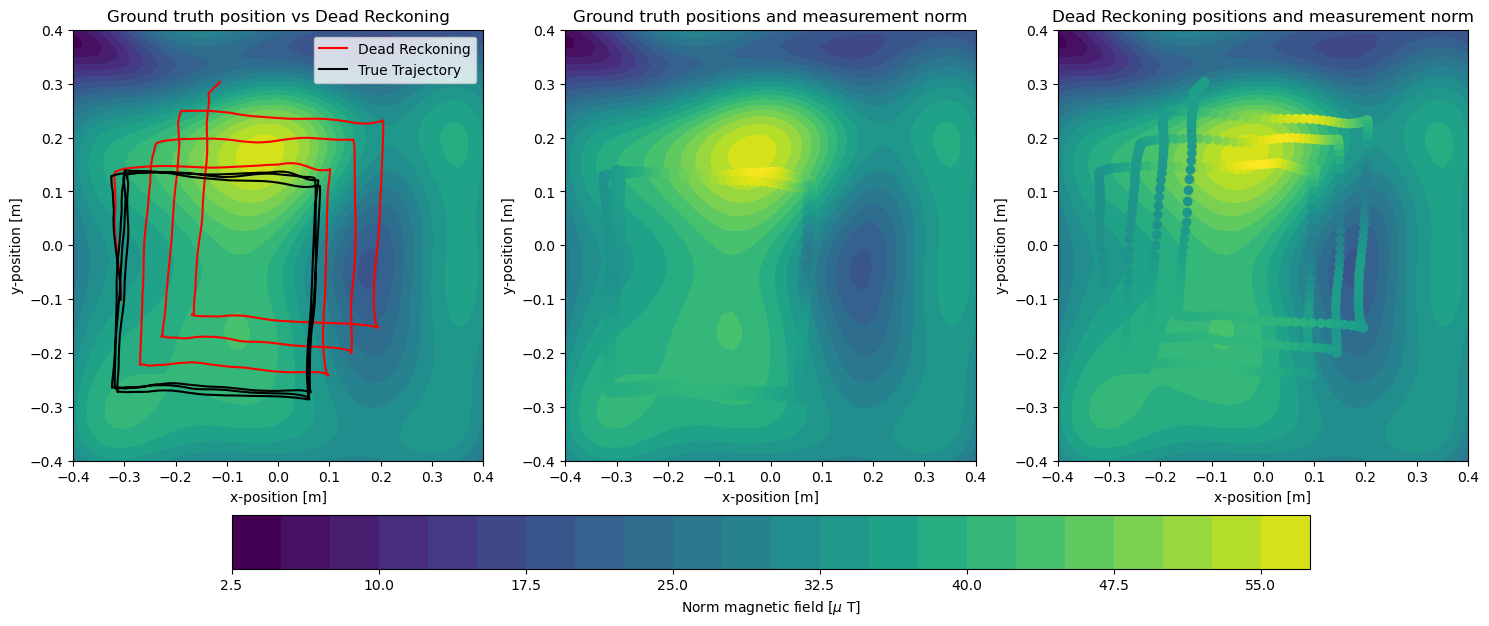

In [59]:
a,N =deltaMagnetometerPositions.shape
deadReckoning = np.zeros((a,N))

deadReckoning[:,0] = magnetometerInitialPosition.T

for i in range(N):
    if i!=0:
        deadReckoning[:,i] = deadReckoning[:,i-1] + deltaMagnetometerPositions[:,i]

magneticFieldNorm = np.linalg.norm(magnetometerMeasurements,axis=0)

helper.makeInitialPositionPlots(deadReckoning, magneticFieldNorm, modelParameters)

### Discuss

Comment below on the three plots. 
- 	Does the dynamic model provide accurate enough information about the agent’s position? What will happen to the position of the agent if it moves for longer periods of time?

~ The dynamic model model provides a rough idea of the agent's position, with respect to the general direction of motion. However, the left most plot shows that the model drifts with time due to the accumulation of measurement noise which is amplified through the errors in the deltaMagnetometerPositions. If left for longer periods of time, the agent's position according this update will drift further away from the true position.

- Based on the magnetic field map shown in the background, explain why or why not the magnetic field is a good source of information for position estimation. 

~ We can use the magnetic field in at a given position to compare and reinforce the belief of the agent's position in the field. This is done by predicting the magnetic field at the position that we think the agent is in (based on our dynamic update) and using the measurement from the magnetometer to see how likely our measurement is for the given particle position, which improves the position estimate . This can be an extremely useful source of information for the implementation of the particle filter. However, the map of the magnetic field is required to be generated beforehand. 

- Explain why the measurements do or do not agree with the magnetic field map (for the middle and the right plots).

~ The magnetic field measurements for each true position in the middle plot roughly agree with the magnetic field map except for the regions where there is a sharp gradient in the magnetic field. This can be due a poor estimation of the magnetic field given the position (which is encased in helper.makeInitialPositionPlots function), this is expected since the magnetic field at any given point is highly non-linear, making it difficult to accurately predict. This variance in information is used while estimating the position of the agent.\
The measurements in the right plot (with deadreckoning) does not agree with the magenetic field because of the drift away from true positions that occurred. This is a way for us to reinforce our belief that there are errors in the deadreckoning position estimates. We can then compare our measured to our expected magnetic field readings to improve our position estimate.  


### Particle Filter Implementation

One way to reduce the positional drift observed in the figure above, is to use magnetometer measurements. To this end, you will design a particle filter. Your task is to fill in the following three functions.

#### Task
Fill in the `dynamicUpdate()` function according to the dynamic model given above. 

#### Note:
You do not have to change the inputs and outputs to the given functions.


In [60]:

def dynamicUpdate(particlePositions, 
                  deltaPosition,
                  processCovariance,
                  Nparticles):
    
    for i in range(Nparticles):

        mean = particlePositions[:,i] + deltaPosition
        particlePositions[:,i] = np.random.multivariate_normal(mean,processCovariance)
        
    return particlePositions


#### Discuss

Comment on the role of the function of the dynamicUpdate in the particle filter

~ The dynamicUpdate is used to propagate all the particles in time (i.e. from $t^{th}$ timestep to $(t+1)^{th}$ timestep), in accordance with the measured deltaPosition and the process Covariance. \
From the given dynamic equation: 
$$\mathbf{p}_{t + 1} = \mathbf{p}_t + \Delta \mathbf{p}_{t+1} + \mathbf{w}_{t+1}$$

Each particle's new position is determined by randomly sampling from the Gaussian distribution:
$$\mathbf{p}_{t + 1} = \mathbf{N(\mathbf{p}_{t + 1} ; \mathbf{p}_t + \Delta \mathbf{p}_{t+1} , Q)}

#### Task

Fill in the `measurementUpdate()` according to the measurement model given above. 

To implement the measurement model, you will need to make predictions of the magnetic field. You DO NOT need to create this function yourself. To make predictions, use the function `GP.makeMagneticFieldPrediction(positions, modelParameters)` function make sure the input `positions` $\in \mathbb{R}^{3 \times N} $. The output should be a matrix $\in \mathbb{R}^{3 \times N}$ magnetic field predictions for every input location.

In [61]:
#function to calculate the probability of x in multivariate Gaussian distribution
def mult_norm(y, mean, cov):

    dist = np.dot(np.dot((y-mean).T,np.linalg.inv(cov)),(y-mean))
    a,b = cov.shape
    det = np.linalg.det(cov)

    prob = np.exp(-0.5*dist)/(pow(2*np.pi,b/2)*pow(det,0.5))

    return prob

In [62]:
def measurementUpdate(particlePositions, 
                      particleWeights,
                      ymeasPF,
                      measurementCovariance,
                      Nparticles,
                      modelParameters):
    
    ''' Measurement update '''
    predictionsMagneticFieldParticles = GP.makeMagneticFieldPrediction(particlePositions, modelParameters)

    #calculating new weights
    for i in range(Nparticles):
        prob = mult_norm(ymeasPF,predictionsMagneticFieldParticles[:,i],measurementCovariance)
        particleWeights[i] = prob*particleWeights[i]
    
    return particlePositions, particleWeights


#### Discuss
Comment on the role of the function of the measurementUpdate in the particle filter

~ This function updates the particle weights based on the measurement likelihood using Bayes' rule. Each new sensor measurement is then compared to the predicted measurements (predicted based on the magnetic field) and its likelihood is updated accordingly. \
\
These weights are then used to resample the particlePositions for the $t+1^{th}$ timestep. This is done by taking:

$$ \mathbf{y}_t = f(\mathbf{p}_t) + \mathbf{v}_t $$

$$ \mathbf{w}^i_{t+1} =  \mathbf{p(y_t | p_t)} \mathbf{w}^i_{t} $$

Where,

$$ \mathbf{p(y_t | p_t)} = \mathbf{N(y_t ; f(p_t) , R)} $$

And, $f(p_t)$ is the "predictionsMagneticFieldParticles"

#### Task

Fill in the remainder of the `particleFilter()` function. 


In [63]:
def particleFilter(particlePositions, 
                   deltaPosition, 
                   ymeasPF, 
                   processCovariance, 
                   measurementCovariance, 
                   Nparticles,
                   modelParameters):
    ''' Estimates position based on a known map'''
    
    particleWeights = np.ones(Nparticles) / Nparticles

    if modelParameters['NtimeStepPF'] > 0:
        ''' Dynamic update '''
        particlePositions = dynamicUpdate(particlePositions, 
                                          deltaPosition, 
                                          processCovariance, 
                                          Nparticles)  

    ''' Measurement update '''
    (particlePositions, 
        particleWeights) = measurementUpdate(particlePositions, 
                                             particleWeights,
                                             ymeasPF, 
                                             measurementCovariance, 
                                             Nparticles,
                                             modelParameters)
    ''' Resampling '''    
    if np.sum(particleWeights) > 1e-12:
        particleWeights /= np.sum(particleWeights)
        indices = helper.systematicResample(particleWeights)
        particlePositions = particlePositions[:, indices]
    else:
        print('Degenerate particles: All the weights are close to zero !!!')
        particleWeights /= np.sum(particleWeights)
        indices = helper.systematicResample(particleWeights)

    meanPosition = np.mean(particlePositions,axis=1)
    maxPosition = np.amax(particlePositions,axis=1)

    return particlePositions, meanPosition, maxPosition


#### Discuss

Comment on the role of the function of the systematicResample in the particle filter

~ Systematic resampling keeps particles with higher weights and those with lower weights are thrown out in favour of heigher weight particles. We do this so that we can successively improve our estimates, and remove particle positions that are less likely. 

Outside of the function we also check if all the particles have zero probabilities and warn the user of them so they can realise that either the distribution or the initial particle position is wrong.

#### Task 4

Choose a suitable amount of particles, an initial position covariance, a suitable motion covariance and a suitable measurement covariance.

You could start with the following parameters
- `initalPositionCovariance` = np.eye(3)*0
- `Nparticles` = 100
- `processCovariance` = np.eye(3)*0.001**2
- `measurementCovariance` = np.eye(3)*1.5**2

To get better results, you might have to tune these. 

In [64]:
''' Number of particles used in the particle filter '''
Nparticles = 100


''' Inital position covariance of the position '''
initalPositionCovariance = np.eye(3)*0


''' process covariance and measurement covariance '''
processCovariance = np.eye(3)*0.001**2
measurementCovariance = np.eye(3)*1.5**2

''' Initialize particle positions '''
a,N = deltaMagnetometerPositions.shape

particlePositions = np.zeros((a,Nparticles))
for i in range(Nparticles):
    particlePositions[:,i] = magnetometerInitialPosition.T + np.random.multivariate_normal(np.zeros((3)) ,initalPositionCovariance)


''' Create matrices to store mean and best particle position at every time-step'''
meanParticlePosition = np.zeros((a,modelParameters['NtimeSteps']-1))
bestParticlePosition = np.zeros((a,modelParameters['NtimeSteps']-1))

''' Initialize and run  the Particle Filter '''
modelParameters['NtimeStepPF'] = 0
for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosPF = deltaMagnetometerPositions[:,timendx]
    ymeasPF = magnetometerMeasurements[:,timendx]
    # print(f'Timestep:',timendx)
    (particlePositions, 
     meanParticlePosition[:, timendx], 
     bestParticlePosition[:, timendx],) = particleFilter(particlePositions, 
                                                          deltaPosPF, 
                                                          ymeasPF, 
                                                          processCovariance, 
                                                          measurementCovariance, 
                                                          Nparticles,
                                                          modelParameters)

    modelParameters['NtimeStepPF'] += 1


### Visualize the output

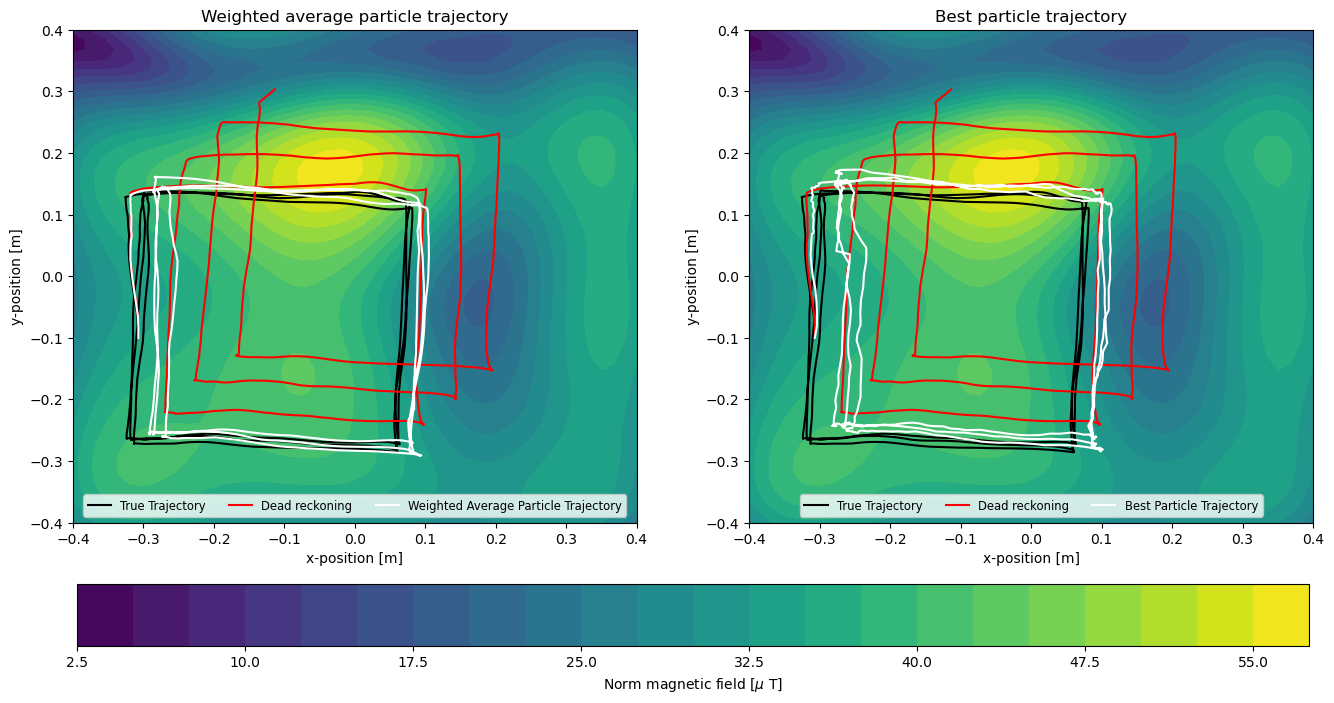

In [65]:
helper.makeParticleFilterPlots(deadReckoning, meanParticlePosition, bestParticlePosition, modelParameters)

#### Discuss

Elaborate on the two plots.
- Does the particle filter improve the position estimates?

~ Yes, it tracks the true position better than dead reckoning. The particle filter performs better than just using the dynamic model by using a Bayesian approach to the problem. It accounts for the noise in both the dynamic model and also incorporates the measurement of the magnetic field (from the magnetometer). This leads to an improved estimate of the position over the previously calculated deadReckoning. 

- Are the weighted average particle trajectory and the best particle trajectory the same or different? Why is that the case?

~ Yes,they are different. In fact the "best" particle trajectory performs worse at tracking the true position. The weighted average particle trajectory uses the mean positions (the most likely ones), whereas the best particle trajectory uses the maximum particle positions for each particle. This "best/max" is not necessarily the most likely, it is just the maximum particle position. So it makes sense that it is further from the true trajectory that the weighted average.


#### Task

Play around with different parameters. Comment on what happens if we choose lower or higher values and reason about why this is the case:
- `initalPositionCovariance`: A value of zero indicates full confidence in the initial position. A value of 1 indicates high uncertainty. We know that the initial position is correct, so we should set this value to zero (or close to).

- `Nparticles`: As we increase N particles we have a larger sample set to test. With good choices in the three covariances, a larger number of particles increases our accuracy of tracking the true positions. But, this comes at a computational cost - it takes longer and is more intensive to run.

- `processCovariance`: We are very certain that the process model is pretty close to correct, with some small uncertainty so we should set this value to be something very small (like 0.001). If we increase the process covariance to 1 (showing less certainty in the model) then we get poor results: either degenerate particles or a map of seemingly random and messy lines across the page with no pattern to the trajectory. If we decrease it to something smaller than 0.001, then we get something that resembles deadreckoning because it is assuming that the delta magnetometer position is very certain and does not need to be corrected for the noise.

- `measurementCovariance`: We know there are errors in the measurements so we need to pick something higher than 0. Lower this results in a higher certainty of our magnetic field measurements and tends to squeeze in the trajectory, while increasing higher it results in the particleFilter giving similar to the deadReckoning positions (given we keep processCovariance small).  We also need to take into account the relationship inherent in our calculations between measurement and process covariance. We can't be equally certain about both because then the model is confused about which corrections to favour. We know we are more certain of our process than our measurements so we should keep that value lower than the measurement covariance. If we don't do this, we get initially good results that track the true position, but then at later points in time the position drifts far beyond the true position and the dead reckoning.

In [ ]:
''' Number of particles used in the particle filter '''
Nparticles = 150


''' Inital position covariance of the position '''
initalPositionCovariance = np.eye(3)*0


''' process covariance and measurement covariance '''
processCovariance = np.eye(3)*0.002**2
measurementCovariance = np.eye(3)*1.2**2

''' Initialize particle positions '''
a,N = deltaMagnetometerPositions.shape
particlePositions = np.zeros((a,Nparticles))
for i in range(Nparticles):
    particlePositions[:,i] = magnetometerInitialPosition.T + np.random.multivariate_normal(np.zeros((3)) ,initalPositionCovariance)


''' Create matrices to store mean and best particle position at every time-step'''
meanParticlePosition = np.zeros((a,modelParameters['NtimeSteps']-1))
bestParticlePosition = np.zeros((a,modelParameters['NtimeSteps']-1))

''' Initialize and run  the Particle Filter '''
modelParameters['NtimeStepPF'] = 0
for timendx in range(modelParameters['NtimeSteps']-1):
    deltaPosPF = deltaMagnetometerPositions[:,timendx]
    ymeasPF = magnetometerMeasurements[:,timendx]
    # print(f'Timestep:',timendx)
    (particlePositions, 
     meanParticlePosition[:, timendx], 
     bestParticlePosition[:, timendx],) = particleFilter(particlePositions, 
                                                          deltaPosPF, 
                                                          ymeasPF, 
                                                          processCovariance, 
                                                          measurementCovariance, 
                                                          Nparticles,
                                                          modelParameters)

    modelParameters['NtimeStepPF'] += 1


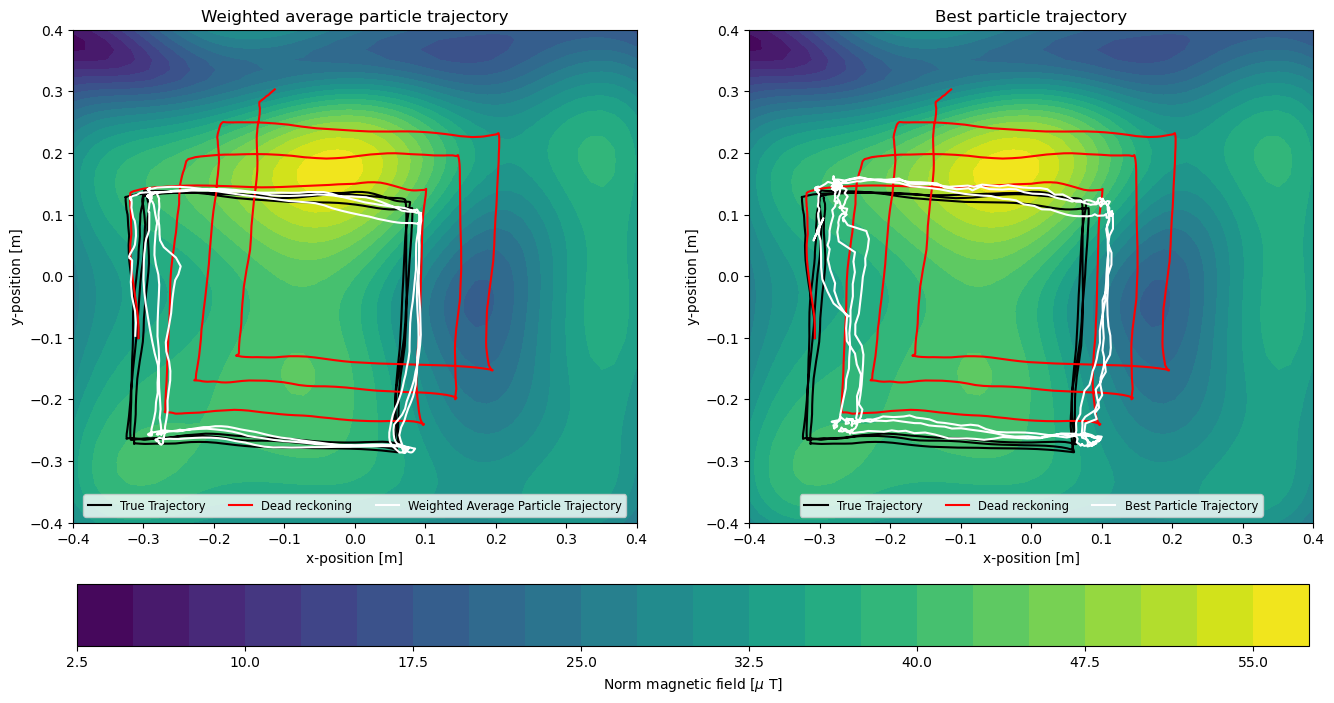

In [69]:
helper.makeParticleFilterPlots(deadReckoning, meanParticlePosition, bestParticlePosition, modelParameters)

#### Discuss

Comment on the reason for choosing a particle filter for this estimation problem.

~ A particle filter is useful to estimate the trajectory based on uncertain and noisy processes and measurements. Since this estimation problem has a highly non-linear function in the magnetic field estimate $\mathbf{f(p)}$ at every position $\mathbf{p}$, using a particle filter is prefered. Since this non-linear function cannot be estimated accurately using a linearlized model, an Extended Kalman Filter or Unscented Kalman filter would yield poor results.
Particle Filters are also better in terms of computational effort that Bayesian grid approximations. We want high accuracy in the region of our position approximation. With a grid this means we need a fine mesh (small grids) but this leaves large areas of many grid elements redundant in locations far from the true position. Whereas with particles we can use many particles which quickly centre around the true position, given a good initial position estimate, and don't waste computational effort calculating low likelihoods far from the true positions.  